In [10]:
import xarray as xr
import pandas as pd
import cartopy.crs as ccrs
import cartopy.feature as cfeature

import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

import numpy as np
import itertools

from atlas14_map_functions import *

In [2]:
aris = ['100','1000']
durations = ['24','48','72']

lists = [durations, aris]

combos=[]
for element in itertools.product(*lists):
    combos = combos + [element]

combos_str = []
for combo in combos:
    res = ' '.join(combo)
    combos_str = combos_str + [res]

combos_str


['24 100', '24 1000', '48 100', '48 1000', '72 100', '72 1000']

In [12]:
## define a colormap (optional)
cmap_data = [(1.000000, 1.000000, 1.000000),
(0.77734375, 0.91015625, 0.75),
(0.62890625, 0.84765625, 0.60546875),
(0.453125, 0.765625, 0.4609375),
(0.19140625, 0.63671875, 0.32421875),
(0.0, 0.42578125, 0.171875),
(1.0, 0.9803921568627451, 0.5411764705882353),
(1.0, 0.8, 0.30980392156862746),
(0.996078431372549, 0.5529411764705883, 0.23529411764705882),
(0.9882352941176471, 0.3058823529411765, 0.16470588235294117),
(0.8392156862745098, 0.10196078431372549, 0.10980392156862745),
(0.6784313725490196, 0.0, 0.14901960784313725),
(0.4392156862745098, 0.0, 0.14901960784313725),
(0.23137254901960785, 0.0, 0.18823529411764706),
(0.2980392156862745, 0.0, 0.45098039215686275),
(1.0, 0.8588235294117647, 1.0)]
cmap = mcolors.ListedColormap(cmap_data, 'precip_nws')

#clevs = [0,0.01,0.1,0.25,0.5,1.00,1.5,2,3,4,6,8,10,15,20,30,50]  ## inches
#clevs = [0,1,2.5,5,10,25,50,75,100,125,150,200,250,350,500,750,1000]  ## mm
clevs = [10,25,50,75,100,125,150,200,250,350,500,750,1000]  ## mm
#norm = mcolors.BoundaryNorm(clevs, cmap.N)

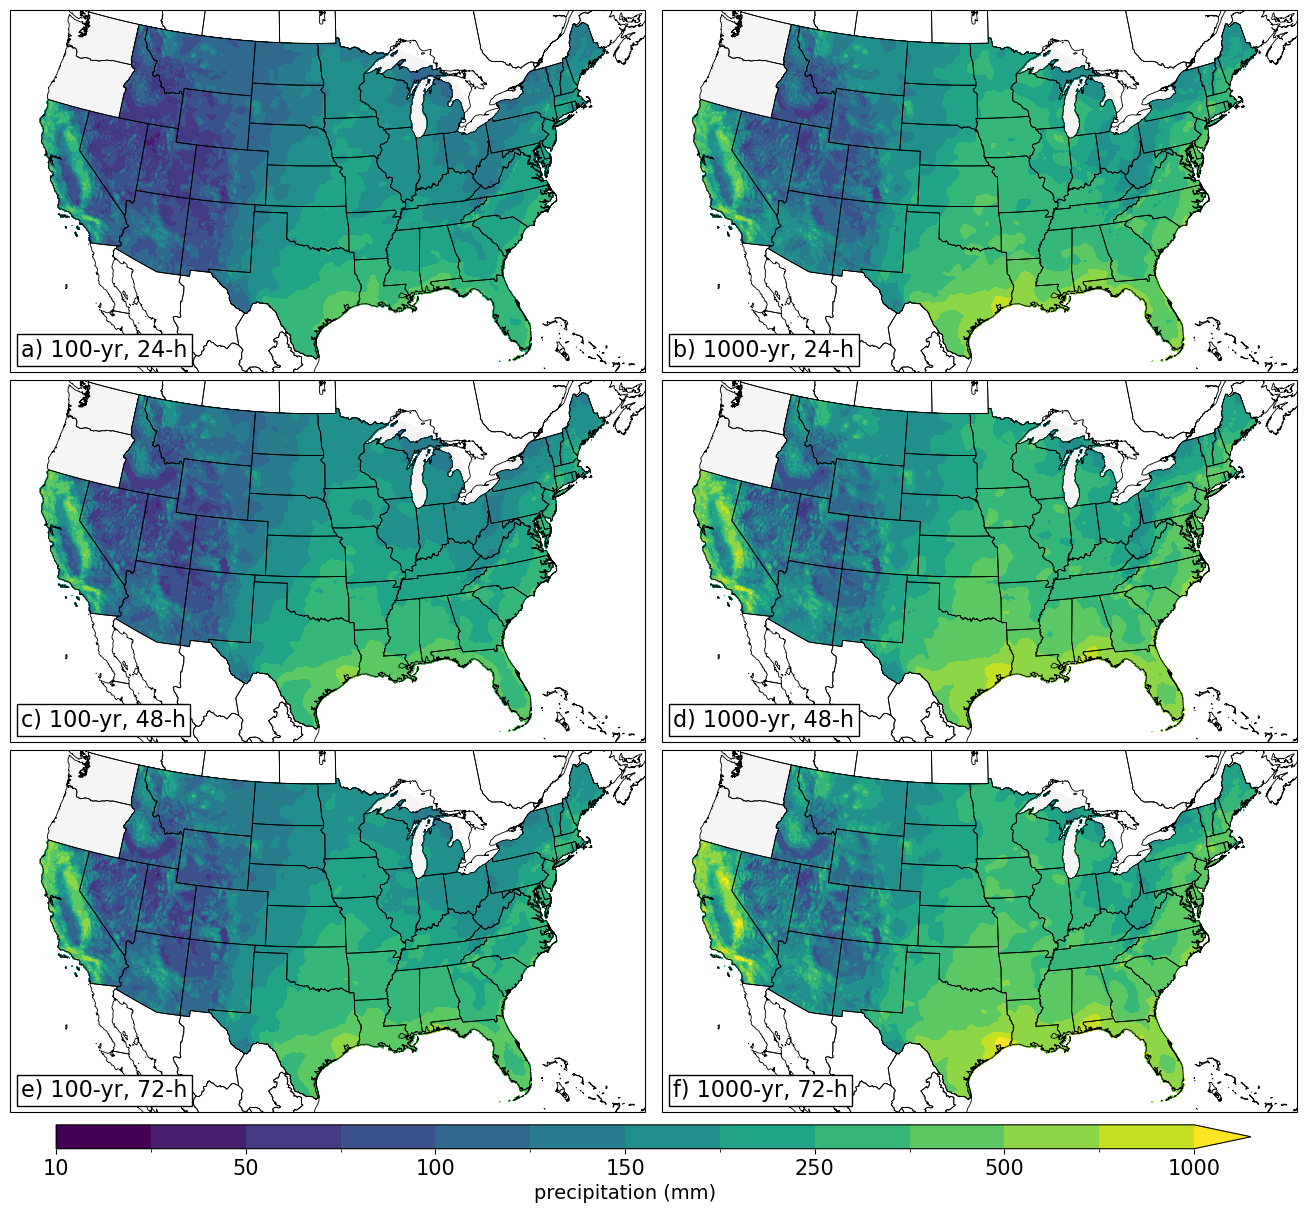

In [16]:
crs = ccrs.LambertConformal(central_longitude=-97.5, central_latitude=35)

panel_letter = 'a'
counter = 0

figsize=(13,12)

fig, ax_dict = plt.subplot_mosaic( 
        [combos_str[0:2],
         combos_str[2:4],
         combos_str[4:6],
        ],
            figsize=figsize, 
            constrained_layout=True,
            subplot_kw={'projection': crs})

axlist=[]  ### this is for the overall colorbar
for k, ax in ax_dict.items():
    plot_background(ax,-121.,-72.,22.1,49.1)
    axlist=axlist+[ax]

for combo in combos_str:

    ari = int(combo.split(' ')[1])
    duration = int(combo.split(' ')[0])

    data = xr.open_dataset("/glade/campaign/univ/ucsu0118/atlas14/allusa_ari_"+str(ari)+"yr_"+str(duration)+"hr_xarray_prismgrid_nopnw.nc")

    cmap=mpl.colormaps['viridis']
    norm = mcolors.BoundaryNorm(clevs, cmap.N, extend='max')
    
    lon2d, lat2d = np.meshgrid(data.lon,data.lat)
    cf = ax_dict[combo].contourf(lon2d, lat2d, data['precip'], 
                     clevs,
                    cmap=cmap,norm=norm,
                                # cmap='viridis',
                                 extend='max',
                     transform_first=True,
                     transform=ccrs.PlateCarree())

    ###panel title
    #ax_dict[combo].set_title(str(ari)+"-yr, "+str(duration)+"-h",
    #                         fontsize=16)

    ### add panel label
    label = chr(ord(panel_letter) + counter)
    ax_dict[combo].annotate(
        label+") "+str(ari)+"-yr, "+str(duration)+"-h",
        xy=(0, 0), xycoords='axes fraction',
        xytext=(+0.5, +1.5), textcoords='offset fontsize',
        fontsize=16, verticalalignment='top',
        bbox=dict(facecolor='white', edgecolor='black', pad=3.0))
    
    counter += 1

### add overall colorbar
cb = plt.colorbar(cf, ax=axlist, orientation='horizontal', 
             aspect=50, shrink=0.925, pad=0.01)
cb.ax.tick_params(labelsize=15) # Set the desired font size here
cb.set_label('precipitation (mm)', fontsize=14)

plt.savefig("na14_ari_multipanel.png")

plt.show()
plt.close('all')

In [4]:
for ari in aris:
    for accum in accums:
        
        print("ari = "+str(ari)+", accum = "+str(accum))

        data = xr.open_dataset("/glade/campaign/univ/ucsu0118/atlas14/allusa_ari_"+str(ari)+"yr_"+str(accum)+"hr_xarray_prismgrid_nopnw.nc")

        crs = ccrs.LambertConformal(central_longitude=-100.0, central_latitude=45.0)

        fig = plt.figure(figsize=(12,8))
        ax = fig.add_subplot(1, 1, 1, projection=crs)

        bounds = [(-122., -75., 24.5, 50.)]
        ax.set_extent(*bounds, crs=ccrs.PlateCarree())
        ax.add_feature(cfeature.COASTLINE.with_scale('50m'), linewidth=1)
        ax.add_feature(cfeature.STATES, linewidth=0.75)
        ax.add_feature(cfeature.BORDERS, linewidth=0.5)

        ## define a colormap (optional)
        cmap_data = [(1.000000, 1.000000, 1.000000),
        (0.77734375, 0.91015625, 0.75),
        (0.62890625, 0.84765625, 0.60546875),
        (0.453125, 0.765625, 0.4609375),
        (0.19140625, 0.63671875, 0.32421875),
        (0.0, 0.42578125, 0.171875),
        (1.0, 0.9803921568627451, 0.5411764705882353),
        (1.0, 0.8, 0.30980392156862746),
        (0.996078431372549, 0.5529411764705883, 0.23529411764705882),
        (0.9882352941176471, 0.3058823529411765, 0.16470588235294117),
        (0.8392156862745098, 0.10196078431372549, 0.10980392156862745),
        (0.6784313725490196, 0.0, 0.14901960784313725),
        (0.4392156862745098, 0.0, 0.14901960784313725),
        (0.23137254901960785, 0.0, 0.18823529411764706),
        (0.2980392156862745, 0.0, 0.45098039215686275),
        (1.0, 0.8588235294117647, 1.0)]
        cmap = mcolors.ListedColormap(cmap_data, 'precip_nws')

        clevs = [0,0.01,0.1,0.25,0.5,1.00,1.5,2,3,4,6,8,10,15,20,30,50]
        norm = mcolors.BoundaryNorm(clevs, cmap.N)

        lon2d, lat2d = np.meshgrid(data.lon,data.lat)
        cf = ax.contourf(lon2d, lat2d, data['precip']/25.4, 
                         clevs,
                         #[5,10,20,30,40,50,60,70,80,90,100,125,150],
                        cmap=cmap,norm=norm,extend='max',
                         transform_first=True,
                         transform=ccrs.PlateCarree())

        plt.title(str(ari)+"-year, "+str(accum)+"-hour average recurrence interval (inches)",
                 fontweight='semibold',fontsize=13)

        cb = fig.colorbar(cf, ax=ax,orientation='horizontal', aspect=30, shrink=0.7, pad=0.01)
        cb.set_label('precip (inches)', size='large')

        #plt.show()
        fig.savefig("ari_"+str(ari)+"yr_"+str(accum)+"hr.png",bbox_inches='tight',
                    dpi=300,facecolor='white',transparent=False)

        plt.close('all')

ari = 1, accum = 1
ari = 1, accum = 3
ari = 1, accum = 6
ari = 1, accum = 24
ari = 1, accum = 48
ari = 1, accum = 72
ari = 1, accum = 96
ari = 1, accum = 168
ari = 2, accum = 1
ari = 2, accum = 3
ari = 2, accum = 6
ari = 2, accum = 24
ari = 2, accum = 48
ari = 2, accum = 72
ari = 2, accum = 96
ari = 2, accum = 168
ari = 5, accum = 1
ari = 5, accum = 3
ari = 5, accum = 6
ari = 5, accum = 24
ari = 5, accum = 48
ari = 5, accum = 72
ari = 5, accum = 96
ari = 5, accum = 168
ari = 10, accum = 1
ari = 10, accum = 3
ari = 10, accum = 6
ari = 10, accum = 24
ari = 10, accum = 48
ari = 10, accum = 72
ari = 10, accum = 96
ari = 10, accum = 168
ari = 25, accum = 1
ari = 25, accum = 3
ari = 25, accum = 6
ari = 25, accum = 24
ari = 25, accum = 48
ari = 25, accum = 72
ari = 25, accum = 96
ari = 25, accum = 168
ari = 50, accum = 1
ari = 50, accum = 3
ari = 50, accum = 6
ari = 50, accum = 24
ari = 50, accum = 48
ari = 50, accum = 72
ari = 50, accum = 96
ari = 50, accum = 168
ari = 100, accum = 1
ari = 1

In [8]:
### repeat for mm
for ari in aris:
    for accum in accums:
        
        print("ari = "+str(ari)+", accum = "+str(accum))

        data = xr.open_dataset("allusa_ari_"+str(ari)+"yr_"+str(accum)+"hr_xarray_prismgrid.nc")

        crs = ccrs.LambertConformal(central_longitude=-100.0, central_latitude=45.0)

        fig = plt.figure(figsize=(12,8))
        ax = fig.add_subplot(1, 1, 1, projection=crs)

        bounds = [(-122., -75., 24.5, 50.)]
        ax.set_extent(*bounds, crs=ccrs.PlateCarree())
        ax.add_feature(cfeature.COASTLINE.with_scale('50m'), linewidth=1)
        ax.add_feature(cfeature.STATES, linewidth=0.75)
        ax.add_feature(cfeature.BORDERS, linewidth=0.5)

        ## define a colormap (optional)
        cmap_data = [(1.000000, 1.000000, 1.000000),
        (0.77734375, 0.91015625, 0.75),
        (0.62890625, 0.84765625, 0.60546875),
        (0.453125, 0.765625, 0.4609375),
        (0.19140625, 0.63671875, 0.32421875),
        (0.0, 0.42578125, 0.171875),
        (1.0, 0.9803921568627451, 0.5411764705882353),
        (1.0, 0.8, 0.30980392156862746),
        (0.996078431372549, 0.5529411764705883, 0.23529411764705882),
        (0.9882352941176471, 0.3058823529411765, 0.16470588235294117),
        (0.8392156862745098, 0.10196078431372549, 0.10980392156862745),
        (0.6784313725490196, 0.0, 0.14901960784313725),
        (0.4392156862745098, 0.0, 0.14901960784313725),
        (0.23137254901960785, 0.0, 0.18823529411764706),
        (0.2980392156862745, 0.0, 0.45098039215686275),
        (1.0, 0.8588235294117647, 1.0)]
        cmap = mcolors.ListedColormap(cmap_data, 'precip_nws')

        #clevs = [0,0.01,0.1,0.25,0.5,1.00,1.5,2,3,4,6,8,10,15,20,30,50]
        clevs = [0,1,2.5,5,10,25,50,75,100,125,150,200,250,350,500,750,1000]
        norm = mcolors.BoundaryNorm(clevs, cmap.N)

        lon2d, lat2d = np.meshgrid(data.lon,data.lat)
        cf = ax.contourf(lon2d, lat2d, data['precip'], 
                         clevs,
                        cmap=cmap,norm=norm,extend='max',
                         transform_first=True,
                         transform=ccrs.PlateCarree())

        plt.title(str(ari)+"-year, "+str(accum)+"-hour average recurrence interval (mm)",
                 fontweight='semibold',fontsize=13)

        cb = fig.colorbar(cf, ax=ax,orientation='horizontal', aspect=30, shrink=0.7, pad=0.01)
        cb.set_label('precip (mm)', size='large')

        #plt.show()
        fig.savefig("ari_"+str(ari)+"yr_"+str(accum)+"hr_mm.png",bbox_inches='tight',
                    dpi=300,facecolor='white',transparent=False)

        plt.close('all')

ari = 1, accum = 1
ari = 1, accum = 3
ari = 1, accum = 6
ari = 1, accum = 24
ari = 1, accum = 48
ari = 1, accum = 72
ari = 1, accum = 96
ari = 1, accum = 168
ari = 2, accum = 1
ari = 2, accum = 3
ari = 2, accum = 6
ari = 2, accum = 24
ari = 2, accum = 48
ari = 2, accum = 72
ari = 2, accum = 96
ari = 2, accum = 168
ari = 5, accum = 1
ari = 5, accum = 3
ari = 5, accum = 6
ari = 5, accum = 24
ari = 5, accum = 48
ari = 5, accum = 72
ari = 5, accum = 96
ari = 5, accum = 168
ari = 10, accum = 1
ari = 10, accum = 3
ari = 10, accum = 6
ari = 10, accum = 24
ari = 10, accum = 48
ari = 10, accum = 72
ari = 10, accum = 96
ari = 10, accum = 168
ari = 25, accum = 1
ari = 25, accum = 3
ari = 25, accum = 6
ari = 25, accum = 24
ari = 25, accum = 48
ari = 25, accum = 72
ari = 25, accum = 96
ari = 25, accum = 168
ari = 50, accum = 1
ari = 50, accum = 3
ari = 50, accum = 6
ari = 50, accum = 24
ari = 50, accum = 48
ari = 50, accum = 72
ari = 50, accum = 96
ari = 50, accum = 168
ari = 100, accum = 1
ari = 1

### difference between Atlas 2 and Atlas 14 (for interior northwest)

ari = 2, accum = 6


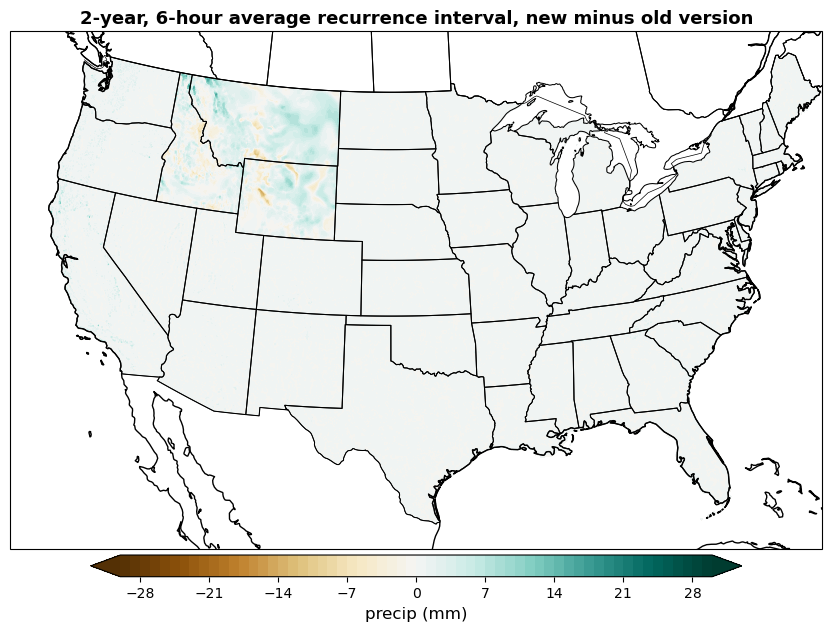

ari = 2, accum = 24


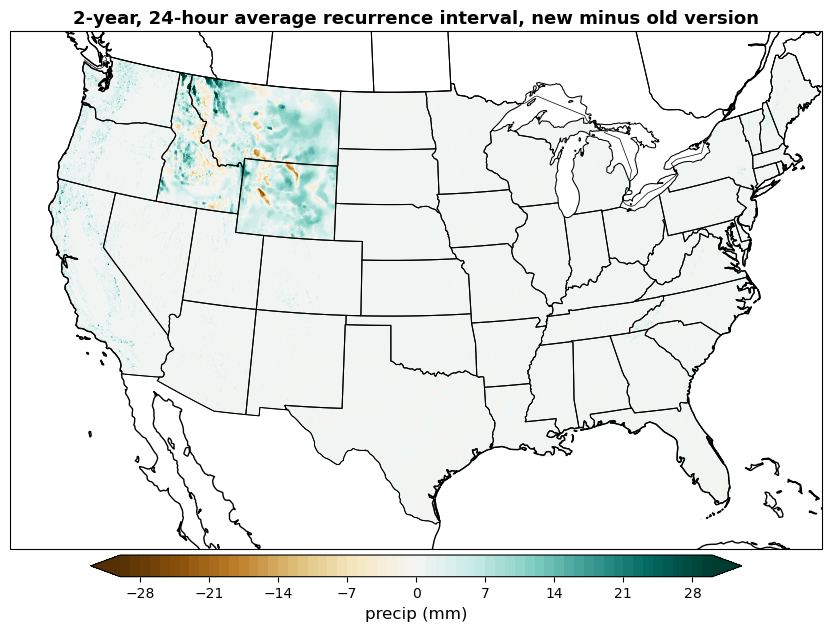

ari = 100, accum = 6


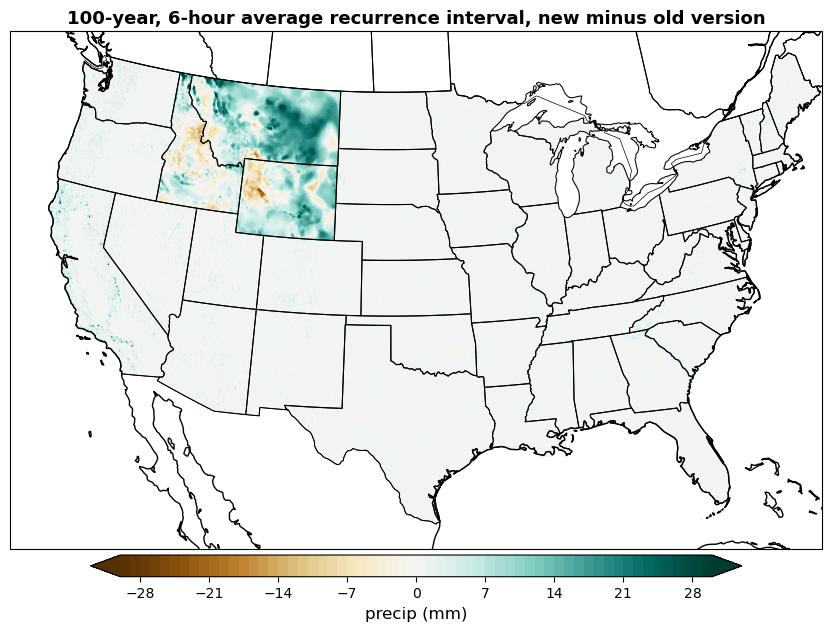

ari = 100, accum = 24


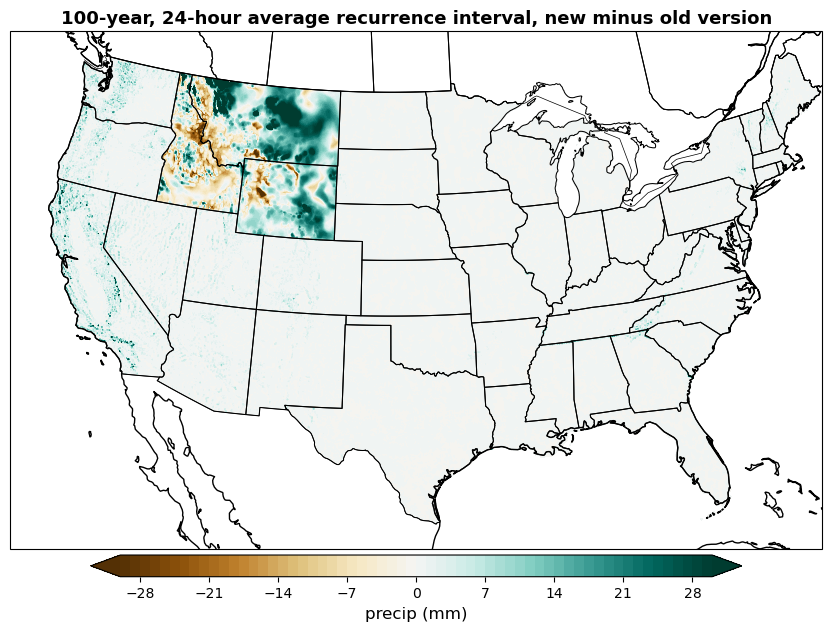

In [9]:
### repeat for mm
for ari in [2,100]:
    for accum in [6,24]:
        
        print("ari = "+str(ari)+", accum = "+str(accum))

        data = xr.open_dataset("allusa_ari_"+str(ari)+"yr_"+str(accum)+"hr_xarray_prismgrid.nc")
        data_old = xr.open_dataset("pre2024/allusa_ari_"+str(ari)+"yr_"+str(accum)+"hr_xarray_prismgrid.nc")

        crs = ccrs.LambertConformal(central_longitude=-100.0, central_latitude=45.0)

        fig = plt.figure(figsize=(12,8))
        ax = fig.add_subplot(1, 1, 1, projection=crs)

        bounds = [(-122., -75., 24.5, 50.)]
        ax.set_extent(*bounds, crs=ccrs.PlateCarree())
        ax.add_feature(cfeature.COASTLINE.with_scale('50m'), linewidth=1)
        ax.add_feature(cfeature.STATES, linewidth=0.75)
        ax.add_feature(cfeature.BORDERS, linewidth=0.5)

        lon2d, lat2d = np.meshgrid(data.lon,data.lat)
        cf = ax.contourf(lon2d, lat2d, 
                         data['precip'].values - data_old['precip'].values, 
                         np.arange(-30,31,1),
                        # clevs,
                        cmap=BrBG_11.mpl_colormap,
                         #norm=norm,
                         extend='both',
                         transform_first=True,
                         transform=ccrs.PlateCarree())

        plt.title(str(ari)+"-year, "+str(accum)+"-hour average recurrence interval, new minus old version",
                 fontweight='semibold',fontsize=13)

        cb = fig.colorbar(cf, ax=ax,orientation='horizontal', aspect=30, shrink=0.7, pad=0.01)
        cb.set_label('precip (mm)', size='large')

        plt.show()
        fig.savefig("ari_diff_"+str(ari)+"yr_"+str(accum)+"hr_mm.png",bbox_inches='tight',
                    dpi=300,facecolor='white',transparent=False)

        plt.close('all')